In [17]:
import pandas as pd
import numpy as np
import os
import sys
notebook_dir = os.path.abspath(os.path.dirname(''))
project_root = os.path.dirname(notebook_dir)
sys.path.append(project_root)
import pandas as pd
from src.utils.db_utils import get_connection, execute_query


from src.features import team_level_features_class
from src.models import model
from src.utils.y_variable import build_spread_variable

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

In [18]:
nfl_model=model.NFLPredictor()
nfl_model.build_x_y_variable()

Successfully connected to the database!
Successfully connected to the database!


In [19]:
nfl_model.x_y

,home team deffensive net_pass_yards,away team deffensive net_pass_yards,home team offensive net_pass_yards,away team offensive net_pass_yards,home team deffensive turnovers,away team deffensive turnovers,home team offensive turnovers,away team offensive turnovers,home team deffensive total_yards,away team deffensive total_yards,...,away team offensive rushing efficiency,home team deffensive rushing yards,away team deffensive rushing yards,home team offensive rushing yards,away team offensive rushing yards,home team deffensive rushing tds,away team deffensive rushing tds,home team offensive rushing tds,away team offensive rushing tds,spread
2024_1_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
2024_1_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
2024_1_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8
2024_1_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
2024_1_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024_15_11,178.461538,218.615385,180.615385,206.0,1.153846,2.153846,0.846154,0.846154,284.230769,310.153846,...,3.94831,105.769231,91.538462,190.461538,132.076923,0.692308,0.923077,1.923077,0.923077,14
2024_15_12,206.076923,253.384615,198.076923,241.0,1.307692,1.230769,0.461538,1.384615,323.692308,368.538462,...,5.050249,117.615385,115.153846,111.461538,138.307692,0.461538,0.923077,1.0,1.076923,-23
2024_15_13,212.461538,222.153846,249.0,231.615385,1.153846,1.846154,1.461538,1.153846,339.0,329.076923,...,4.816318,126.538462,106.923077,95.384615,144.692308,0.769231,0.846154,1.230769,1.153846,-17
2024_15_14,250.615385,218.0,238.230769,182.692308,2.076923,1.538462,1.461538,0.769231,337.846154,352.769231,...,4.039763,87.230769,134.769231,113.153846,105.846154,0.538462,1.153846,0.538462,0.923077,18


In [3]:
# model_parameters={"n_estimators": [500,1000, 1500,2000],
#                      "max_depth": [1,3,5,10],
#                      "min_samples_leaf": [.01,.05,.1]}
# nfl_model.build_random_forest_model(model_parameters)

In [4]:
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 2, 3, 4, 5],
    'gamma': [0, 0.1, 0.2, 0.3, 0.4, 0.5]
}

nfl_model.build_xg_boost_model(param_dist)

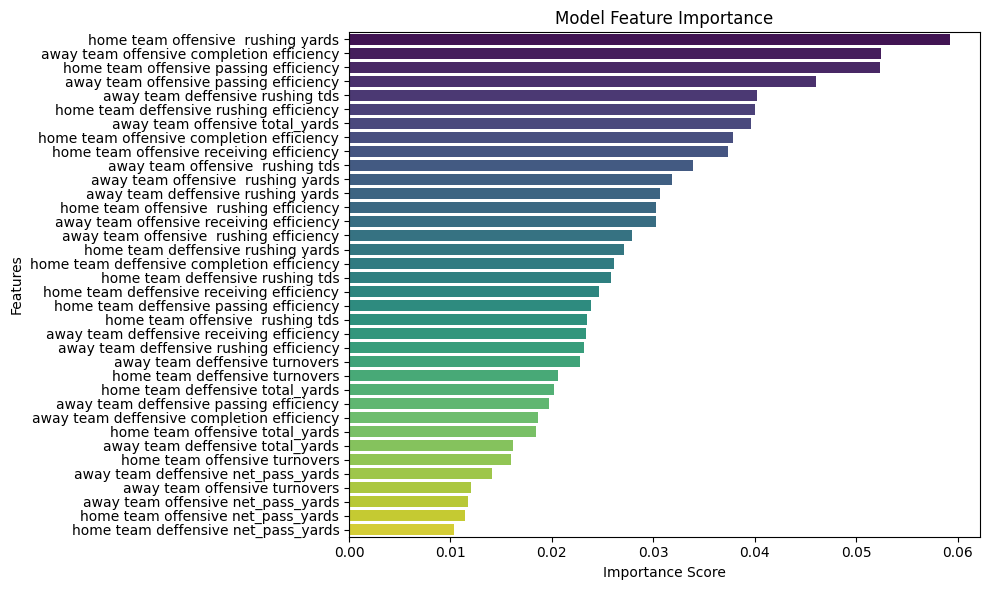

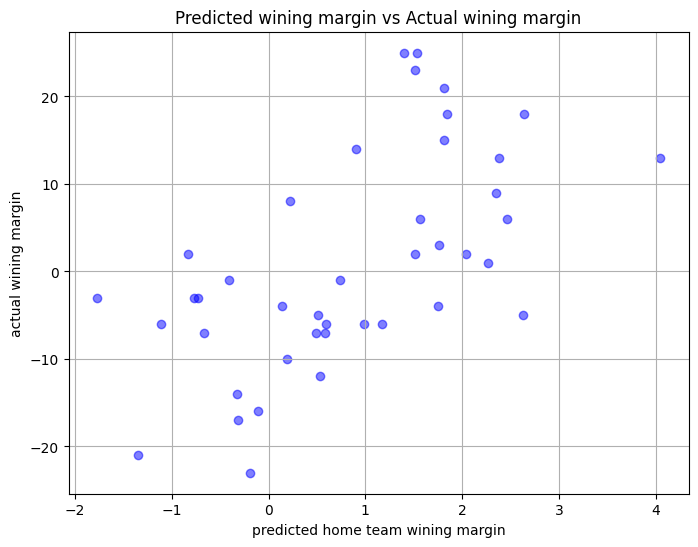

In [5]:
nfl_model.model_prediction(nfl_model.xg_model, x=nfl_model.x_test.to_numpy(),plot_feature_importance=True, plot_scatter=True)

In [6]:
np.array([]).shape[0]

0

In [7]:
strategy_dict_update=[["SFO"],["DET"],[0]]

In [8]:
del nfl_model.spread_dict['2024_15']
nfl_model.spread_dict["2024_15"]=strategy_dict_update

In [9]:
nfl_model.spread_dict["2024_15"]

[['SFO'], ['DET'], [0]]

In [10]:
nfl_model.build_x_y_variable()


In [11]:
nfl_model.x_test=nfl_model.x_y.iloc[:,:-1].dropna().to_numpy()
nfl_model.model_prediction(nfl_model.xg_model)
nfl_model.x_test

array([[139.0, 146.0, 319.0, ..., 1.0, 1.0, 2.0],
       [199.0, 225.0, 135.0, ..., 0.0, 1.0, 1.0],
       [137.0, 135.0, 163.0, ..., 1.0, 1.0, 2.0],
       ...,
       [224.08333333333334, 206.41666666666666, 229.75, ..., 0.5,
        0.9166666666666666, 1.0],
       [212.08333333333334, 241.0, 236.83333333333334, ...,
        1.3333333333333333, 0.3333333333333333, 0.75],
       [182.6153846153846, 224.69230769230768, 239.6153846153846, ...,
        0.9230769230769231, 1.0769230769230769, 1.6923076923076923]],
      dtype=object)

In [12]:
nfl_model.xg_model.n_estimators

300

In [13]:
nfl_model.predictions[-1]

-0.15455665

In [14]:
nfl_model.x_y

,home team deffensive net_pass_yards,away team deffensive net_pass_yards,home team offensive net_pass_yards,away team offensive net_pass_yards,home team deffensive turnovers,away team deffensive turnovers,home team offensive turnovers,away team offensive turnovers,home team deffensive total_yards,away team deffensive total_yards,...,away team offensive rushing efficiency,home team deffensive rushing yards,away team deffensive rushing yards,home team offensive rushing yards,away team offensive rushing yards,home team deffensive rushing tds,away team deffensive rushing tds,home team offensive rushing tds,away team offensive rushing tds,spread
2024_1_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
2024_1_1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
2024_1_2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8
2024_1_3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
2024_1_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024_14_9,215.333333,199.666667,230.833333,219.916667,1.25,2.0,1.0,0.583333,359.5,321.583333,...,4.388685,144.166667,121.916667,100.166667,127.583333,0.833333,0.583333,0.833333,1.75,2
2024_14_10,190.0,209.416667,232.833333,190.083333,1.333333,1.583333,1.583333,0.75,309.916667,344.5,...,4.106569,119.916667,135.083333,139.583333,109.0,1.583333,1.0,0.916667,1.0,25
2024_14_11,224.083333,206.416667,229.75,198.416667,0.833333,1.416667,1.166667,0.5,311.916667,325.833333,...,4.052548,87.833333,119.416667,111.833333,112.916667,0.75,0.5,0.916667,1.0,2
2024_14_12,212.083333,241.0,236.833333,264.333333,1.166667,1.0,1.75,1.083333,359.666667,369.166667,...,4.228336,147.583333,128.166667,85.833333,91.666667,1.75,1.333333,0.333333,0.75,-7


In [15]:
nfl_model.team_feautres.team_stats_dict["deffensive net_pass_yards"]["DET"]

2024_1            NaN
2024_2     304.000000
2024_3     225.000000
2024_4     216.666667
2024_5     258.250000
2024_6     258.250000
2024_7     246.200000
2024_8     245.833333
2024_9     247.571429
2024_10    250.750000
2024_11    244.222222
2024_12    232.700000
2024_13    227.181818
2024_14    226.833333
2024_15    224.692308
Name: DET, dtype: float64